In [1]:
import numpy as np # algebra linear
import pandas as pd # processamento de dados, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt 
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Carregando o dataset 
df = pd.read_csv('/kaggle/input/uber-ride-analytics-dashboard/ncr_ride_bookings.csv')

# Visualizando as primeiras linhas
df.head()



/kaggle/input/uber-ride-analytics-dashboard/ncr_ride_bookings.csv
/kaggle/input/uber-ride-analytics-dashboard/Dasboard.gif
/kaggle/input/uber-ride-analytics-dashboard/Uber.pbix


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [2]:
# Esse comando mostra o nome exato de todas as colunas
print(df.columns)

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='object')


In [3]:
# Criando uma única coluna de data e hora unindo as duas colunas existentes
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

# Criando as colunas auxiliares para análise
df['Hour'] = df['DateTime'].dt.hour
df['DayOfWeek'] = df['DateTime'].dt.day_name()

# Limpeza de valores nulos (importante para não dar erro nos gráficos)
# Vamos focar em colunas numéricas que usaremos para IA
df_clean = df.dropna(subset=['Booking Value', 'Ride Distance'])

print("Dados prontos! Agora temos as colunas 'Hour' e 'DayOfWeek' para os gráficos.")
df[['Date', 'Time', 'DateTime', 'Hour', 'DayOfWeek']].head()

Dados prontos! Agora temos as colunas 'Hour' e 'DayOfWeek' para os gráficos.


,Date,Time,DateTime,Hour,DayOfWeek
0,2024-03-23,12:29:38,2024-03-23 12:29:38,12,Saturday
1,2024-11-29,18:01:39,2024-11-29 18:01:39,18,Friday
2,2024-08-23,08:56:10,2024-08-23 08:56:10,8,Friday
3,2024-10-21,17:17:25,2024-10-21 17:17:25,17,Monday
4,2024-09-16,22:08:00,2024-09-16 22:08:00,22,Monday


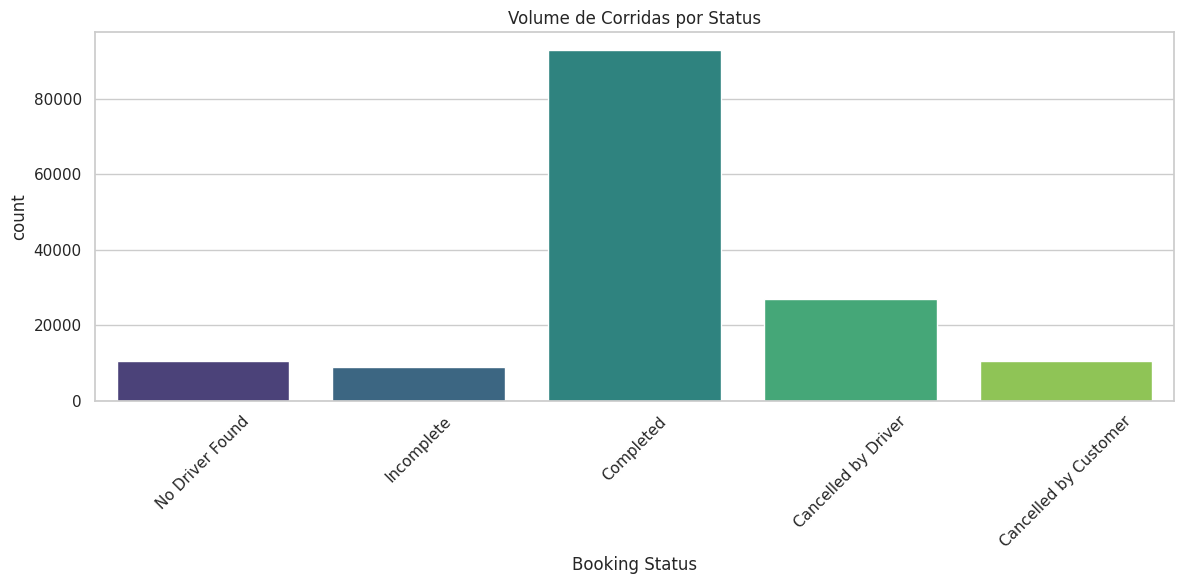

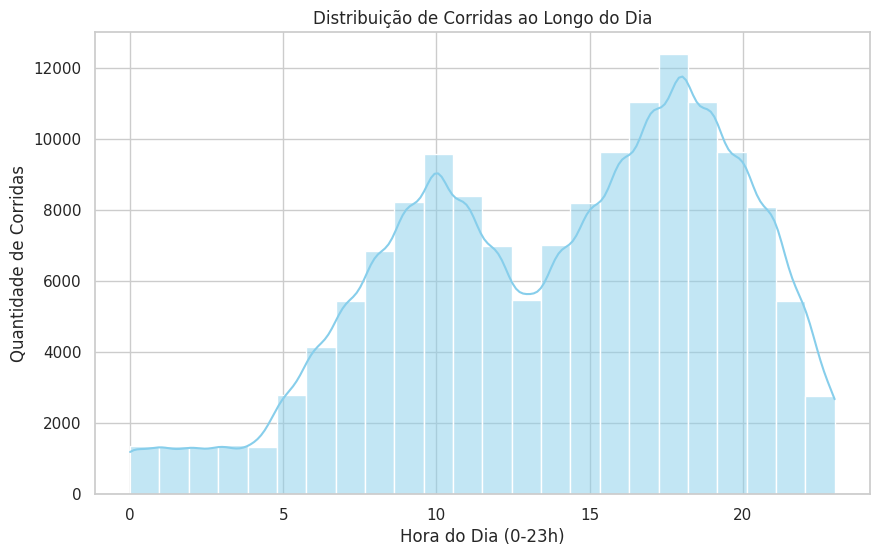

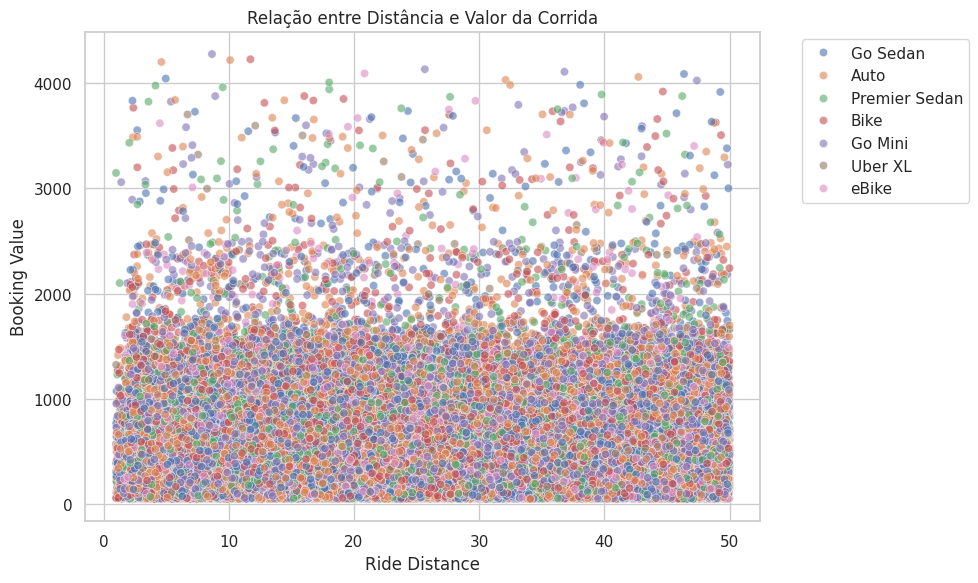

In [4]:
# Configurando o estilo visual
sns.set_theme(style="whitegrid")

# 1. Gráfico de Barras: Status das Corridas
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Booking Status', hue='Booking Status', palette='viridis', legend=False)
plt.title('Volume de Corridas por Status')
plt.xticks(rotation=45)
plt.tight_layout() 
plt.savefig('status_corridas.png')
plt.show()

# 2. Histograma: Picos de Demanda por Hora
plt.figure(figsize=(10,6))
sns.histplot(df['Hour'], bins=24, color='skyblue', kde=True)
plt.title('Distribuição de Corridas ao Longo do Dia')
plt.xlabel('Hora do Dia (0-23h)')
plt.ylabel('Quantidade de Corridas')
plt.savefig('demanda_horaria.png')
plt.show()

# 3. Gráfico de Dispersão: Relação Preço vs Distância
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clean, x='Ride Distance', y='Booking Value', hue='Vehicle Type', alpha=0.6)
plt.title('Relação entre Distância e Valor da Corrida')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # legenda abaixo abaixo do gráfico
plt.tight_layout()
plt.savefig('preco_vs_distancia.png')
plt.show()